In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2,
                           n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

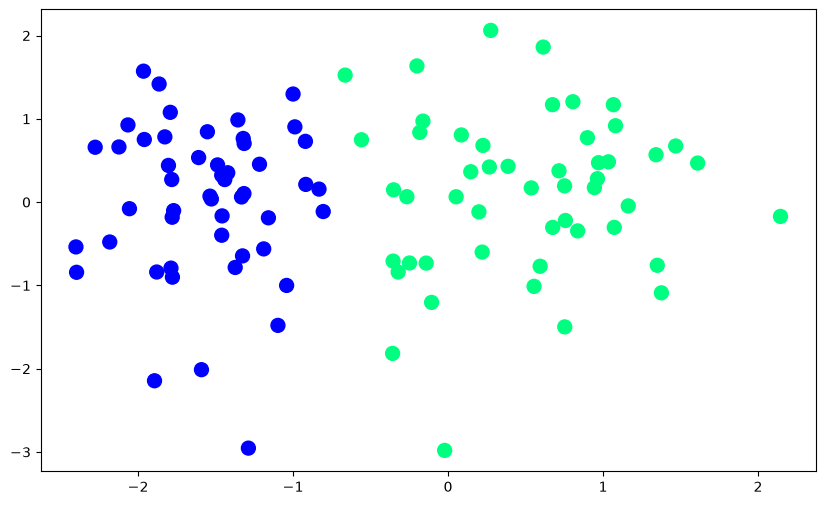

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100)

### Using SKLearn Logistic Regression:

In [4]:
lor = LogisticRegression(C=np.inf, solver='sag', max_iter=2500)
lor.fit(X, y)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'sag'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of t

In [5]:
print(f"Intercept: {lor.intercept_}")
print(f"Coefficients: {lor.coef_}")

Intercept: [19.15670787]
Coefficients: [[28.7227959   2.53421609]]


In [6]:
m = -(lor.coef_[0][0] / lor.coef_[0][1])
b = -(lor.intercept_ / lor.coef_[0][1])

In [7]:
X_input = np.linspace(-3, 3, 100)
y_input = m * X_input + b

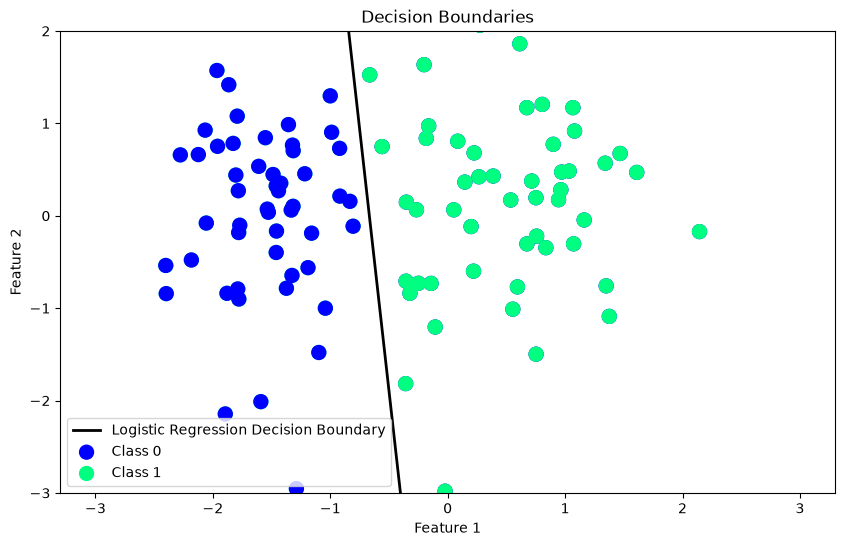

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(X_input, y_input, color='black', label='Logistic Regression Decision Boundary', linewidth=2)
plt.scatter(X[:, 0], X[:, 1], c = 1-y, cmap='winter', s=100, label='Class 0')
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100, label='Class 1')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundaries')
plt.legend()

### Using Gradient Descent approach:

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [10]:
def GD(X, y):

	X = np.insert(X, 0, 1, axis=1)
	weights = np.ones(X.shape[1])
	lr = 0.5

	for i in range(100000):
		y_pred = sigmoid(np.dot(X, weights))
		weights = weights + lr * (np.dot((y - y_pred), X) / X.shape[0])
	return weights[1:], weights[0]

In [11]:
coef_, intercept_ = GD(X, y)

In [12]:
m_new = -(coef_[0] / coef_[1])
b_new = -(intercept_ / coef_[1])

In [13]:
X_input1 = np.linspace(-3, 3, 100)
y_input1 = m_new * X_input1 + b_new

### Comparing Logistic Regression and Gradient Descent approach:

Both approaches optimize the **same underlying objective** — the log-loss (cross-entropy) — just via different routes. Scikit-learn's `LogisticRegression` uses an optimized solver (`sag`) to reach the minimum efficiently, while the manual `GD` function performs the same optimization explicitly: computing the sigmoid-based prediction, comparing it to the true labels, and updating all weights simultaneously using the *average* gradient across the full dataset (batch gradient descent), rather than one random point at a time like the perceptron trick.

This is a key difference from the perceptron trick covered earlier. The perceptron's `step` function produces a hard 0/1 output and updates on one misclassified point at a time, so it stops as soon as it finds *any* zero-error boundary — not necessarily the best one, and it isn't minimizing a smooth loss at all. Here, both methods use the smooth `sigmoid` output and are minimizing the same convex log-loss surface, so given enough iterations, both are expected to converge toward the same optimal decision boundary — which is exactly what the overlapping lines in the plot above are meant to demonstrate.

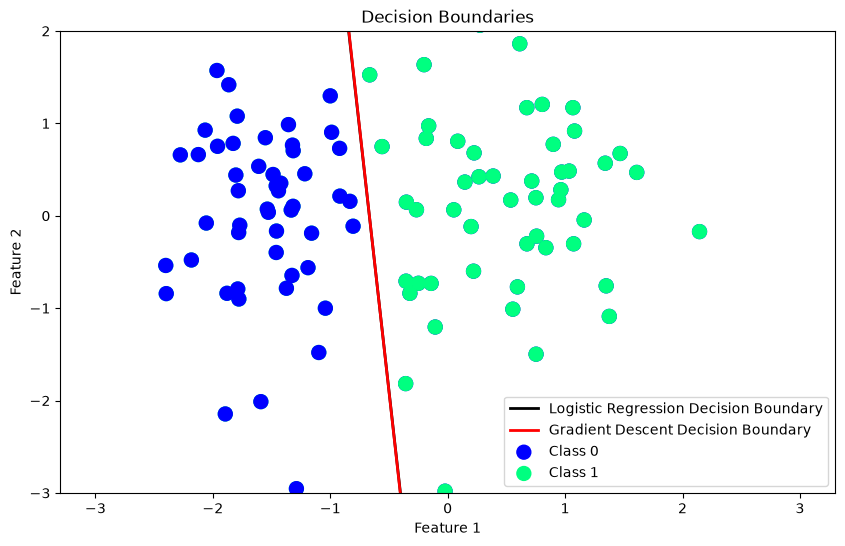

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(X_input, y_input, color='black', label='Logistic Regression Decision Boundary', linewidth=2)
plt.plot(X_input1, y_input1, color='red', label='Gradient Descent Decision Boundary', linewidth=2)
plt.scatter(X[:, 0], X[:, 1], c = 1-y, cmap='winter', s=100, label='Class 0')
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100, label='Class 1')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundaries')
plt.legend()